In [1]:
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install gymnasium pygame moviepy imageio imageio-ffmpeg matplotlib pandas > /dev/null 2>&1

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from base64 import b64encode

# إعداد الشاشة الافتراضية للفيجوال في Colab
os.environ["DISPLAY"] = ":99"
!Xvfb :99 -screen 0 1024x768x24 > /dev/null 2>&1 &

In [4]:
# --------------------------------------------------
# 1. إعداد البيئة والبرامترات الفائقة
# --------------------------------------------------
env_name = "CliffWalking-v1"
env = gym.make(env_name)

n_states = env.observation_space.n
n_actions = env.action_space.n

alpha = 0.1      # Learning Rate
gamma = 0.99     # Discount Factor
eplison = 0.1    # Exploration Rate
episodes = 500   # عدد حلقات التدريب

# دالة اختيار الحركة بأسلوب Epsilon-Greedy
def choose_action(Q, state, eplison):
    if random.uniform(0, 1) < eplison:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

# --------------------------------------------------
# 2. خوارزمية Q-Learning
# --------------------------------------------------
def train_q_learning():
    Q = np.zeros((n_states, n_actions))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = choose_action(Q, state, eplison)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-Learning Update Rule (Off-Policy)
            best_next_action = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next_action] * (1 - float(done))
            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state
            total_reward += reward

        rewards.append(total_reward)
    return Q, rewards

# --------------------------------------------------
# 3. خوارزمية SARSA
# --------------------------------------------------
def train_sarsa():
    Q = np.zeros((n_states, n_actions))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        action = choose_action(Q, state, eplison)
        total_reward = 0
        done = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_action = choose_action(Q, next_state, eplison)

            # SARSA Update Rule (On-Policy)
            td_target = reward + gamma * Q[next_state][next_action] * (1 - float(done))
            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state
            action = next_action
            total_reward += reward

        rewards.append(total_reward)
    return Q, rewards

# --------------------------------------------------
# 4. خوارزمية Expected SARSA
# --------------------------------------------------
def train_expected_sarsa():
    Q = np.zeros((n_states, n_actions))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = choose_action(Q, state, eplison)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # حساب القيمة المتوقعة للإجراء التالي
            best_action = np.argmax(Q[next_state])
            policy_probs = np.ones(n_actions) * (eplison / n_actions)
            policy_probs[best_action] += (1.0 - eplison)

            expected_q = np.dot(Q[next_state], policy_probs)

            # Expected SARSA Update Rule
            td_target = reward + gamma * expected_q * (1 - float(done))
            Q[state][action] += alpha * (td_target - Q[state][action])

            state = next_state
            total_reward += reward

        rewards.append(total_reward)
    return Q, rewards

# --------------------------------------------------
# 5. تشغيل التدريب وتجميع البيانات
# --------------------------------------------------
print("⚡ جارٍ تدريب Q-Learning...")
q_Q, q_rewards = train_q_learning()

print("⚡ جارٍ تدريب SARSA...")
sarsa_Q, sarsa_rewards = train_sarsa()

print("⚡ جارٍ تدريب Expected SARSA...")
exp_sarsa_Q, exp_sarsa_rewards = train_expected_sarsa()

# --------------------------------------------------
# 6. دالة التقييم وتسجيل الفيديو
# --------------------------------------------------
def evaluate_and_record(Q, video_folder):
    eval_env = gym.make(env_name, render_mode="rgb_array")
    eval_env = RecordVideo(eval_env, video_folder=video_folder, episode_trigger=lambda x: True)

    state, _ = eval_env.reset()
    total_reward = 0
    done = False

    while not done:
        action = np.argmax(Q[state]) # اختيار الحركة الأفضل بشكل قطعي (Greedy)
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated

    eval_env.close()
    return total_reward

print("\n📹 تسجيل فيديو لأداء Q-Learning...")
q_eval_reward = evaluate_and_record(q_Q, "./video_q_learning")

print("📹 تسجيل فيديو لأداء SARSA...")
sarsa_eval_reward = evaluate_and_record(sarsa_Q, "./video_sarsa")

print("📹 تسجيل فيديو لأداء Expected SARSA...")
exp_sarsa_eval_reward = evaluate_and_record(exp_sarsa_Q, "./video_expected_sarsa")

⚡ جارٍ تدريب Q-Learning...
⚡ جارٍ تدريب SARSA...
⚡ جارٍ تدريب Expected SARSA...

📹 تسجيل فيديو لأداء Q-Learning...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


📹 تسجيل فيديو لأداء SARSA...
📹 تسجيل فيديو لأداء Expected SARSA...


--- 🎬 فيديو أداء نموذج Q-Learning ---



--- 🎬 فيديو أداء نموذج SARSA ---



--- 🎬 فيديو أداء نموذج Expected SARSA ---


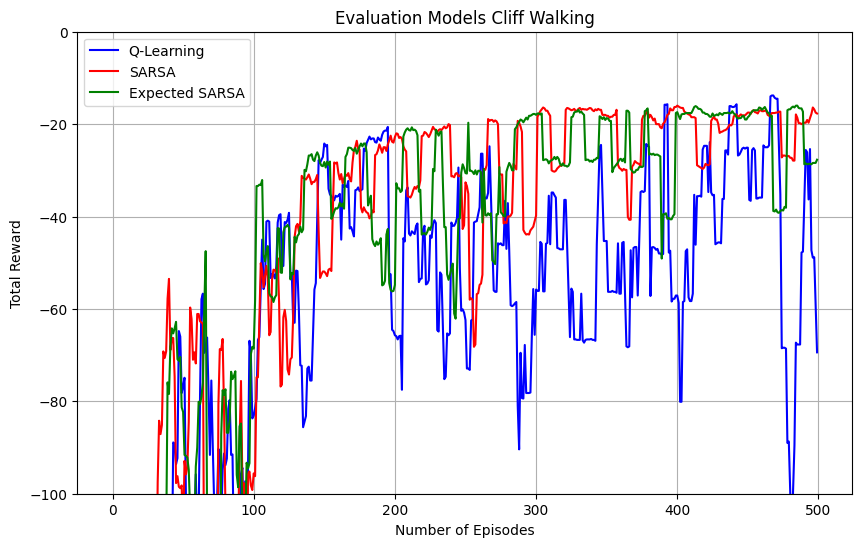

In [7]:
def show_video(video_folder):
    files = [f for f in os.listdir(video_folder) if f.endswith('.mp4')]
    if not files:
        print("لم يتم العثور على فيديو!")
        return
    video_path = os.path.join(video_folder, files[0])
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width=450 controls autoplay loop>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

print("--- 🎬 فيديو أداء نموذج Q-Learning ---")
display(show_video('./video_q_learning'))

print("\n--- 🎬 فيديو أداء نموذج SARSA ---")
display(show_video('./video_sarsa'))

print("\n--- 🎬 فيديو أداء نموذج Expected SARSA ---")
display(show_video('./video_expected_sarsa'))

# --------------------------------------------------
# رسم منحنيات التعلم (Learning Curves)
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# استخدام المتوسط المتحرك لملاحظة الاتجاه العام بوضوح
def smooth(data, window=10):
    return pd.Series(data).rolling(window, min_periods=1).mean()

plt.plot(smooth(q_rewards), label='Q-Learning', color='blue')
plt.plot(smooth(sarsa_rewards), label='SARSA', color='red')
plt.plot(smooth(exp_sarsa_rewards), label='Expected SARSA', color='green')

plt.title('Evaluation Models Cliff Walking')
plt.xlabel('Number of Episodes')
plt.ylabel('Total Reward')
plt.ylim(-100, 0) # التركيز على النطاق المهم
plt.legend()
plt.grid(True)
plt.show()